# NB6 — Tier-C: TileViT / MAE over 162 Solar Cell Tiles (feature-token)

**Env:** `torchfifty`
**Prerequisites:** `TileSetIV_*.pt` (NB3 V5), `lucia_tile_features.parquet`, `norm_stats_tiles_*.json`

| Section | Content |
|---|---|
| §7.1 | Env + imports + hyperparameters + NB3 feature schema (FEAT_COLS) |
| §7.2 | Architecture: TileViT (feature tokenizer) + MAEDecoder + IVHead |
| §7.3 | Tile-feature DataLoader (162×37, mirrors NB3) |
| §7.4 | MAE pre-training (mask tile tokens, reconstruct 37-d features) |
| §7.5 | IV fine-tuning: frozen encoder → full unfreeze (NLL + physics) |
| §7.6 | Evaluation vs NB3 TileSetIV (R² per target) |
| §7.7 | Summary |

**Approach:** Each cell is represented as 162 tokens (9 rows × 18 cols, the NB3/NB4 tile grid),
where **each token is that tile's 37-dimensional engineered feature vector** — the exact features
Tier-A's MIL pooling consumes — rather than raw pixels. This keeps Tier-A's information **and** adds
cross-tile self-attention (the lever Tier-A's pooling lacks, targeting Rs). MAE pre-training masks
a fraction of tile tokens and reconstructs their feature vectors, forcing the encoder to learn
cross-tile structure. IV fine-tuning mirrors NB3 loss exactly (same YJ params, same physics
constraints).

**Acceptance:** feature-token Tier-C should reach **≥ Tier-A on Rs and Pmax** (Tier-A §6.1:
FF 0.886, Pmax 0.778, **Rs 0.598**).

In [8]:
# ── §7.1  Env + imports ───────────────────────────────────────────────────────
import os, sys, json, glob, math
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

N_CORES = os.cpu_count() or 4
torch.set_num_threads(N_CORES)

_LUCIA_ROOT = os.environ.get('LUCIA_ROOT',
    '/storage/homefs/db98d082/ondemand/LUCIA'
    if os.path.isdir('/storage/homefs/db98d082') else
    '/home/derk/DataScience/CAS_projects/LUCIA')
sys.path.insert(0, str(Path(_LUCIA_ROOT) / 'notebooks_scripts'))
import lucia_common as lc

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
SEED   = 42
torch.manual_seed(SEED); np.random.seed(SEED)

# Image + tile geometry
IMG_H_UBX, IMG_W_UBX = 288, 576
IN_CH_UBX  = 2              # el_hi + pl_hi  (legacy pixel geometry — kept for reference)
TILE_ROWS  = 9
TILE_COLS  = 18
TILE_H     = IMG_H_UBX // TILE_ROWS   # 32
TILE_W     = IMG_W_UBX // TILE_COLS   # 32
N_TILES    = TILE_ROWS * TILE_COLS    # 162

IV_TARGETS = ['Voc', 'Isc', 'Vmax', 'Imax', 'FF', 'Pmax', 'Rs']
N_IV       = len(IV_TARGETS)
RECON_IDX  = [lc.RAW_CHANNELS.index('el_hi'), lc.RAW_CHANNELS.index('pl_hi')]

# ViT / MAE architecture hyperparameters
D_MODEL    = 256
N_HEADS    = 8
DEPTH_ENC  = 6
D_DEC      = 64
DEPTH_DEC  = 2
MASK_RATIO = 0.5      # feature tokens are information-denser than pixels (was 0.75 for pixels)

# Training schedule — feature-token input is cheap; budget raised from the 50ep prototype.
MAE_EPOCHS    = 200   # feature-token MAE (37-d tokens) — fast; 200-400 fits an H100 session
FT_FROZEN_EP  = 40   # Stage 1: IV head + frozen encoder — the stable main stage
FT_FULL_EP    = 15   # Stage 2: SHORT partial unfreeze (last 2 blocks only), low LR
WARMUP_NLL    = 20    # MSE warm-up; β-NLL (+ real per-target weights) after
BETA_NLL      = 0.641 # β-NLL exponent — match Tier-A (stops σ collapse over poor μ)
LOGVAR_MIN    = -2.0  # σ-floor: σ_min = exp(-1) ≈ 0.37 — keeps β-NLL from running away
LAMBDA_C      = 0.1   # physics constraint weight (mirrors NB3)
BATCH         = 64
LR_MAE        = 1e-4
LR_FT         = 5e-5
LR_FULL       = 1e-6   # Stage-2 partial unfreeze: 10x lower than the head LR

H5_STACKS = os.path.join(lc.PROCESSED, 'cell_stacks.h5')

for d in [lc.MODELS, lc.FIGURES, lc.PROCESSED]:
    os.makedirs(d, exist_ok=True)

print(f'torch {torch.__version__}  device: {DEVICE}  RUN_ID: {RUN_ID}')
print(f'Tile: {TILE_H}x{TILE_W}px  N_tiles={N_TILES}  tokens/image={N_TILES}')
print(f'ViT: d={D_MODEL} depth={DEPTH_ENC} heads={N_HEADS}')
print(f'MAE pre-train: {MAE_EPOCHS}ep  Fine-tune: {FT_FROZEN_EP}+{FT_FULL_EP}ep')

# ── §7.1b  Feature schema from the NB3 Tier-A checkpoint (PART B1) ────────────
# Each tile token is the 37-d engineered feature vector Tier-A uses — NOT pixels.
# FEAT_COLS / N_FEAT are authoritative from the checkpoint; never hand-typed.
def _latest(pattern):
    fs = sorted(glob.glob(pattern))
    assert fs, f"No files match {pattern}"
    return fs[-1]

_nb3_glob = [c for c in sorted(glob.glob(os.path.join(lc.MODELS, 'TileSetIV_*.pt')))
             if '_ep' not in os.path.basename(c)]
assert _nb3_glob, 'No NB3 TileSetIV_*.pt checkpoint in lc.MODELS — run NB3 first.'
_nb3_path = _nb3_glob[-1]
nb3_ckpt  = torch.load(_nb3_path, map_location='cpu', weights_only=False)
FEAT_COLS = list(nb3_ckpt['feat_cols'])          # authoritative 37-name order
N_FEAT    = len(FEAT_COLS)
assert N_FEAT == 37, N_FEAT
_nf       = json.load(open(_latest(os.path.join(lc.PROCESSED, 'norm_stats_tiles_*.json'))))
feat_mu   = np.asarray(_nf['mean'], np.float32)  # (37,)
feat_sd   = np.asarray(_nf['std'],  np.float32)  # (37,)
assert feat_mu.shape == (N_FEAT,) and feat_sd.shape == (N_FEAT,), (feat_mu.shape, feat_sd.shape)
print(f"NB3 checkpoint: {os.path.basename(_nb3_path)}")
print(f"FEAT_COLS={N_FEAT}  norm stats loaded  (same schema as NB3/Tier-A)")

torch 2.2.0  device: cuda  RUN_ID: 20260630_144408
Tile: 32x32px  N_tiles=162  tokens/image=162
ViT: d=256 depth=6 heads=8
MAE pre-train: 200ep  Fine-tune: 40+15ep
NB3 checkpoint: TileSetIV_20260628_213323.pt
FEAT_COLS=37  norm stats loaded  (same schema as NB3/Tier-A)


In [9]:
# ── §7.2  Architecture: TileViT + MAEDecoder + IVHead ─────────────────────────
# Tokens are the 37-d engineered tile features (PART B), not pixels.

class TileViT(nn.Module):
    # Projects each tile's 37-d feature vector into a d_model token via Linear.
    # forward()          → CLS token (B, D_MODEL) for IV prediction.
    # forward_encoder()  → all N+1 tokens (B, N+1, D) for MAE decoding.
    def __init__(self, n_feat=N_FEAT,
                 n_rows=TILE_ROWS, n_cols=TILE_COLS,
                 d_model=D_MODEL, n_heads=N_HEADS, depth=DEPTH_ENC):
        super().__init__()
        self.n_tiles = n_rows * n_cols
        self.d_model = d_model
        # Feature tokenizer: each tile's 37-dim feature vector → d_model token
        self.feat_proj = nn.Linear(n_feat, d_model)
        # Learnable 2D positional embedding
        self.pos_embed  = nn.Parameter(torch.zeros(1, n_rows * n_cols, d_model))
        self.cls_token  = nn.Parameter(torch.zeros(1, 1, d_model))
        self.mask_token = nn.Parameter(torch.zeros(1, 1, d_model))
        for p in [self.pos_embed, self.cls_token, self.mask_token]:
            nn.init.trunc_normal_(p, std=0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=4 * d_model,
            dropout=0.0, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=depth)
        self.norm    = nn.LayerNorm(d_model)

    def tokenize(self, feats):                 # feats: (B, 162, 37)
        return self.feat_proj(feats) + self.pos_embed      # (B, 162, d_model)

    def forward_encoder(self, feats, mask=None):
        # mask: (B, N) bool — True = tile replaced with mask_token
        tokens = self.tokenize(feats)
        if mask is not None:
            mt     = self.mask_token.expand(tokens.shape[0], tokens.shape[1], -1)
            tokens = torch.where(mask.unsqueeze(-1), mt, tokens)
        cls    = self.cls_token.expand(feats.shape[0], -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)   # (B, N+1, D)
        return self.norm(self.encoder(tokens))

    def forward(self, feats, mask=None):
        return self.forward_encoder(feats, mask)[:, 0]  # CLS token → (B, D)


class MAEDecoder(nn.Module):
    # Lightweight 2-layer decoder: project encoder tokens → reconstruct masked tile features.
    def __init__(self, d_model=D_MODEL, d_dec=D_DEC, n_heads=4, depth=DEPTH_DEC,
                 n_feat=N_FEAT, n_tiles=N_TILES):
        super().__init__()
        self.proj          = nn.Linear(d_model, d_dec)
        self.pos_embed_dec = nn.Parameter(torch.zeros(1, n_tiles + 1, d_dec))
        nn.init.trunc_normal_(self.pos_embed_dec, std=0.02)
        dec_layer = nn.TransformerEncoderLayer(
            d_model=d_dec, nhead=n_heads, dim_feedforward=4 * d_dec,
            dropout=0.0, batch_first=True, norm_first=True)
        self.decoder = nn.TransformerEncoder(dec_layer, num_layers=depth)
        self.pred    = nn.Linear(d_dec, n_feat)            # reconstruct the 37-d tile feature

    def forward(self, tokens):
        # tokens: (B, N+1, d_model) — skip CLS in output
        x = self.proj(tokens) + self.pos_embed_dec
        x = self.decoder(x)
        return self.pred(x[:, 1:])   # (B, N, n_feat)


class IVHead(nn.Module):
    # 7 heteroscedastic regression heads — mirrors NB3 _IVHeads exactly.
    def __init__(self, d_model=D_MODEL, n_iv=N_IV, hidden=64):
        super().__init__()
        self.heads = nn.ModuleList([
            nn.Sequential(nn.Linear(d_model, hidden), nn.GELU(), nn.Linear(hidden, 2))
            for _ in range(n_iv)
        ])
    def forward(self, z):
        out = []
        for h in self.heads:
            p = h(z)
            out.append(torch.stack([p[:, 0], p[:, 1].clamp(LOGVAR_MIN, 2.0)], dim=1))
        return torch.stack(out, dim=1)   # (B, N_IV, 2)


vit     = TileViT().to(DEVICE)
mae_dec = MAEDecoder().to(DEVICE)
iv_head = IVHead().to(DEVICE)

n_vit  = sum(p.numel() for p in vit.parameters())
n_dec  = sum(p.numel() for p in mae_dec.parameters())
n_head = sum(p.numel() for p in iv_head.parameters())
print(f'TileViT:    {n_vit:,} params  (d={D_MODEL} depth={DEPTH_ENC} heads={N_HEADS}, n_feat={N_FEAT})')
print(f'MAEDecoder: {n_dec:,} params  (d_dec={D_DEC} depth={DEPTH_DEC} -> {N_FEAT}-d)')
print(f'IVHead:     {n_head:,} params  (7 heteroscedastic heads)')

# Sanity check — feature tokens (B, 162, 37)
with torch.no_grad():
    _x   = torch.randn(2, N_TILES, N_FEAT).to(DEVICE)
    _cls = vit(_x)
    _tok = vit.forward_encoder(_x)
    _feat_pred = mae_dec(_tok)
    _iv  = iv_head(_cls)
    print(f'Feature tokens: {list(_x.shape)} -> CLS {list(_cls.shape)}')
    print(f'All tokens:  {list(_tok.shape)}')
    print(f'MAE pred:    {list(_feat_pred.shape)}  (B, {N_TILES}, {N_FEAT})')
    print(f'IV pred:     {list(_iv.shape)}  OK')
    assert _feat_pred.shape == (2, N_TILES, N_FEAT), _feat_pred.shape
    assert _iv.shape == (2, N_IV, 2), _iv.shape

TileViT:    4,790,784 params  (d=256 depth=6 heads=8, n_feat=37)
MAEDecoder: 129,253 params  (d_dec=64 depth=2 -> 37-d)
IVHead:     116,046 params  (7 heteroscedastic heads)
Feature tokens: [2, 162, 37] -> CLS [2, 256]
All tokens:  [2, 163, 256]
MAE pred:    [2, 162, 37]  (B, 162, 37)
IV pred:     [2, 7, 2]  OK


/storage/homefs/db98d082/.conda/envs/mod3cuda/lib/python3.10/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [10]:
# ── §7.3  Tile-feature DataLoader (37-d engineered features per tile) ─────────
# Each cell → (162, 37) feature matrix, tiles row-major (9×18) via sort_index() on
# the (cell_name, tile_id) MultiIndex — identical ordering to NB3/NB4. Mirrors NB3's
# loader: X = tile_df.loc[cn].sort_index()[FEAT_COLS].values.

# lucia_tile_features.parquet has a (cell_name, tile_id) MultiIndex; reading only the
# FEAT_COLS columns restores that index from the pandas metadata.
_tile_df = pd.read_parquet(lc.TILE_PARQUET, columns=FEAT_COLS).sort_index()
assert list(_tile_df.index.names) == ['cell_name', 'tile_id'], _tile_df.index.names
print(f"Tile features: {lc.TILE_PARQUET}")
print(f"  {_tile_df.shape[0]:,} tile rows  {_tile_df.shape[1]} feature cols")


class TileFeatDataset(Dataset):
    def __init__(self, names, cells_df, tile_df, feat_cols, mu, sd, iv_targets):
        self.names = list(names)
        self.tile  = tile_df
        self.cols  = list(feat_cols)
        self.mu    = mu.astype(np.float32); self.sd = sd.astype(np.float32)
        self.iv    = cells_df.loc[self.names, iv_targets].values.astype(np.float32)
    def __len__(self): return len(self.names)
    def __getitem__(self, i):
        cn  = self.names[i]
        X   = self.tile.loc[cn].sort_index()[self.cols].values.astype(np.float32)  # (162,37)
        assert X.shape == (N_TILES, N_FEAT), (cn, X.shape)
        X   = (X - self.mu) / (self.sd + 1e-6)
        return torch.from_numpy(X), torch.from_numpy(self.iv[i])


cells, geom = lc.load_parquets()
coh_mask    = lc.modeling_mask(cells, geom, paired=False)

# Restrict to cells that have a complete 162-tile feature set in the parquet.
_n_per_cell = _tile_df.groupby(level='cell_name').size()
_full_cells = set(_n_per_cell[_n_per_cell == N_TILES].index)

def _split_names(split):
    return [n for n in coh_mask[coh_mask & cells['split'].eq(split)].index if n in _full_cells]

tr_names = _split_names('train')
va_names = _split_names('val')
te_names = _split_names('test')

ds_tr = TileFeatDataset(tr_names, cells, _tile_df, FEAT_COLS, feat_mu, feat_sd, IV_TARGETS)
ds_va = TileFeatDataset(va_names, cells, _tile_df, FEAT_COLS, feat_mu, feat_sd, IV_TARGETS)
ds_te = TileFeatDataset(te_names, cells, _tile_df, FEAT_COLS, feat_mu, feat_sd, IV_TARGETS)
dl_tr = DataLoader(ds_tr, batch_size=BATCH, shuffle=True,  num_workers=8, pin_memory=True)
dl_va = DataLoader(ds_va, batch_size=BATCH, shuffle=False, num_workers=4, pin_memory=True)
dl_te = DataLoader(ds_te, batch_size=BATCH, shuffle=False, num_workers=4, pin_memory=True)

print(f'Train: {len(ds_tr):,} cells ({len(dl_tr)} batches)   '
      f'Val: {len(ds_va):,}   Test: {len(ds_te):,}')

# Smoke-print one batch: shape (B, 162, 37), standardized.
_fb, _ivb = next(iter(dl_tr))
print(f'Batch feats: {list(_fb.shape)}  dtype={_fb.dtype}  '
      f'range=[{_fb.min():.2f},{_fb.max():.2f}]  mean={_fb.mean():.3f} std={_fb.std():.3f}')
assert _fb.shape[1:] == (N_TILES, N_FEAT), _fb.shape

Tile features: /storage/homefs/db98d082/ondemand/LUCIA/data/processed/lucia_tile_features.parquet
  1,699,704 tile rows  37 feature cols
Train: 7,293 cells (114 batches)   Val: 1,570   Test: 1,564
Batch feats: [64, 162, 37]  dtype=torch.float32  range=[-19.84,29.52]  mean=0.009 std=0.918


MAE pre-training (200 epochs, mask_ratio=0.5, AMP=on)...


MAE:   8%|▊         | 17/200 [00:46<05:40,  1.86s/it]

  ep25  mae_loss=0.25416  best=0.24218  [ckpt]


MAE:  17%|█▋        | 34/200 [01:32<05:07,  1.85s/it]

  ep50  mae_loss=0.21196  best=0.21196  [ckpt]


...

  ep150  mae_loss=0.14462  best=0.13825  [ckpt]


MAE:  85%|████████▌ | 170/200 [05:20<00:54,  1.82s/it]

  ep175  mae_loss=0.14158  best=0.13825  [ckpt]


MAE: 100%|██████████| 200/200 [06:06<00:00,  1.83s/it]


  ep200  mae_loss=0.15223  best=0.13248  [ckpt]
MAE saved: /storage/homefs/db98d082/ondemand/LUCIA/models/tierc_vit_mae_20260630_144408.pt  best_loss=0.13248


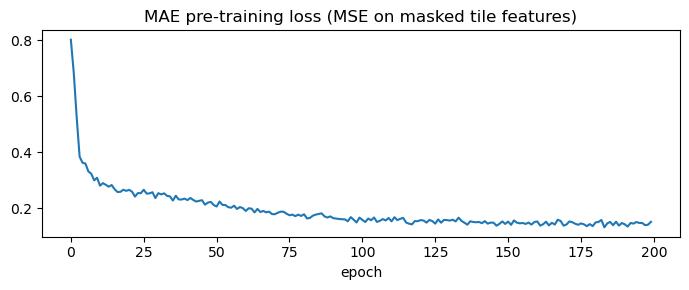

In [11]:
# ── §7.4  MAE Pre-training ────────────────────────────────────────────────────
# Mask 50% of tile tokens randomly, reconstruct the masked tiles' 37-d feature vectors.
# Loss: MSE on masked tokens only (not visible tokens — avoids trivial copy).
# AMP (bfloat16) for speed.

from torch.cuda.amp import autocast, GradScaler

def random_mask(B, N, ratio, device):
    n_mask = int(N * ratio)
    ids    = torch.argsort(torch.rand(B, N, device=device), dim=1)
    mask   = torch.zeros(B, N, dtype=torch.bool, device=device)
    mask.scatter_(1, ids[:, :n_mask], True)
    return mask   # True = masked


if dl_tr is None:
    print('Skip §7.4 — DataLoader not available (run §7.3 first).')
else:
    # ── resume support ────────────────────────────────────────────────────────
    RESUME_MAE = None  # set to checkpoint path to resume, e.g.:
                       # os.path.join(lc.MODELS, f'tierc_vit_mae_{RUN_ID}_ep010.pt')
    START_EP   = 0
    if RESUME_MAE and os.path.exists(str(RESUME_MAE)):
        _rc = torch.load(RESUME_MAE, map_location='cpu', weights_only=False)
        vit.load_state_dict(_rc['vit']); mae_dec.load_state_dict(_rc['decoder'])
        START_EP = _rc.get('epoch', 0) + 1
        print(f'Resumed: {os.path.basename(str(RESUME_MAE))}  start_ep={START_EP}')

    scaler     = GradScaler()
    CKPT_EVERY = 25   # checkpoint every 25 ep — survives session timeouts
    params_mae = list(vit.parameters()) + list(mae_dec.parameters())
    opt_mae    = torch.optim.AdamW(params_mae, lr=LR_MAE, weight_decay=0.05)
    sched_mae  = torch.optim.lr_scheduler.CosineAnnealingLR(opt_mae, T_max=MAE_EPOCHS)

    log_mae = []
    best_mae_loss, best_vit_mae, best_dec_mae = float('inf'), None, None

    print(f'MAE pre-training ({MAE_EPOCHS} epochs, mask_ratio={MASK_RATIO}, AMP=on)...')
    for epoch in tqdm(range(START_EP, MAE_EPOCHS), desc='MAE', mininterval=30):
        vit.train(); mae_dec.train(); tr_loss = 0.0

        for feats, _ in dl_tr:
            feats = feats.to(DEVICE)               # (B, 162, 37) standardized features
            B     = feats.shape[0]
            mask  = random_mask(B, N_TILES, MASK_RATIO, DEVICE)

            tgt = feats                            # reconstruct the input feature tokens

            with autocast():
                tokens     = vit.forward_encoder(feats, mask)
                feat_pred  = mae_dec(tokens)       # (B, 162, 37)
                loss       = F.mse_loss(feat_pred[mask], tgt[mask].to(feat_pred.dtype))

            opt_mae.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(opt_mae); scaler.update()
            tr_loss += loss.item()

        sched_mae.step()
        tr_loss /= len(dl_tr)
        log_mae.append({'epoch': epoch, 'tr': tr_loss})

        if tr_loss < best_mae_loss:
            best_mae_loss = tr_loss
            best_vit_mae  = {k: v.cpu() for k, v in vit.state_dict().items()}
            best_dec_mae  = {k: v.cpu() for k, v in mae_dec.state_dict().items()}

        if (epoch + 1) % CKPT_EVERY == 0:
            ep_ckpt = os.path.join(lc.MODELS, f'tierc_vit_mae_{RUN_ID}_ep{epoch+1:03d}.pt')
            torch.save({'vit': best_vit_mae, 'decoder': best_dec_mae,
                        'run_id': RUN_ID, 'epoch': epoch}, ep_ckpt)
            tqdm.write(f'  ep{epoch+1}  mae_loss={tr_loss:.5f}  best={best_mae_loss:.5f}  [ckpt]')

    vit.load_state_dict(best_vit_mae)
    mae_final = os.path.join(lc.MODELS, f'tierc_vit_mae_{RUN_ID}.pt')
    torch.save({'vit': best_vit_mae, 'decoder': best_dec_mae,
                'run_id': RUN_ID, 'best_mae_loss': best_mae_loss,
                'd_model': D_MODEL, 'depth': DEPTH_ENC, 'n_heads': N_HEADS,
                'n_feat': N_FEAT, 'n_tiles': N_TILES},
               mae_final)
    print(f'MAE saved: {mae_final}  best_loss={best_mae_loss:.5f}')

    fig, ax = plt.subplots(figsize=(7, 3))
    pd.DataFrame(log_mae).plot('epoch', 'tr', ax=ax, legend=False)
    ax.set(title='MAE pre-training loss (MSE on masked tile features)', xlabel='epoch')
    plt.tight_layout()
    fig.savefig(os.path.join(lc.FIGURES, f'nb6_mae_loss_{RUN_ID}.png'), dpi=120, bbox_inches='tight')
    plt.show()

YJ params loaded from: TileSetIV_20260628_213323.pt
Stage 1: frozen encoder (40 epochs)...


FT-frozen:  18%|█▊        | 7/40 [00:21<01:13,  2.22s/it]

  ep9  tr=0.3532  min_r2=-0.536  mean_r2=+0.095  smooth=-0.298


FT-frozen:  38%|███▊      | 15/40 [00:42<00:53,  2.13s/it]

  ep19  tr=0.3041  min_r2=-0.515  mean_r2=+0.133  smooth=-0.522
[β-NLL start] per-target weights from val MSE: {'Voc': 0.903, 'Isc': 1.512, 'Vmax': 0.633, 'Imax': 0.962, 'FF': 0.821, 'Pmax': 0.67, 'Rs': 1.5}


...

  ep44  tr=-0.1024  min_r2=-4.634  mean_r2=-1.043  smooth=-4.176


FT-partial:  40%|████      | 6/15 [00:28<00:25,  2.79s/it]

  ep49  tr=-0.1046  min_r2=-4.660  mean_r2=-1.095  smooth=-4.661


FT-partial: 100%|██████████| 15/15 [00:42<00:00,  2.80s/it]


  ep54  tr=-0.1051  min_r2=-4.951  mean_r2=-1.136  smooth=-4.951
Fine-tune checkpoint saved: /storage/homefs/db98d082/ondemand/LUCIA/models/tierc_vit_ft_20260630_144408.pt  best_min_r2(smooth)=+0.0705


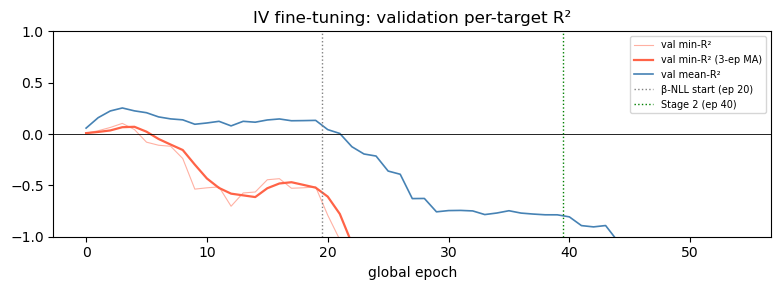

In [12]:
# ── §7.5  IV Fine-tuning: β-NLL + difficulty-weighted, partial Stage-2 ────────
# Fixes (per review of the bad β-NLL run):
#  1. Per-target weights are REAL: set at warm-up end from each target's val MSE
#     (up-weight the worst, e.g. FF/Vmax) — not 1/var(y_sc), which is ~1 for all.
#  2. Stage 2 does NOT fully unfreeze (that thrashed): only the last 2 encoder
#     blocks + final norm, 10x lower LR, ~15 ep. Stage 1 (frozen) is the main stage.
#  3. Grad clipping + higher σ-floor (LOGVAR_MIN=-2.0) keep the NLL bounded.
#  4. Selection is on the 3-epoch moving average of min-per-target val R² (no spikes).

if dl_tr is None:
    print('Skip §7.5 — DataLoader not available.')
else:
    from sklearn.metrics import r2_score

    # ── Load YJ transform params from NB3 checkpoint ──────────────────────────
    nb3_ckpts = sorted([c for c in glob.glob(os.path.join(lc.MODELS, 'TileSetIV_*.pt'))
                        if '_ep' not in os.path.basename(c)])
    assert nb3_ckpts, 'No NB3 TileSetIV checkpoint — run NB3 §4.4 first.'
    nb3_ckpt  = torch.load(nb3_ckpts[-1], map_location='cpu', weights_only=False)
    pt_params = nb3_ckpt['pt_params']   # {target: {lambda, mu, std}}
    print(f'YJ params loaded from: {os.path.basename(nb3_ckpts[-1])}')

    def _yj_fwd(y, lam):
        out = torch.zeros_like(y)
        pos = y >= 0
        if abs(lam) < 1e-6:
            out[pos]  =  torch.log1p(y[pos])
            out[~pos] = -(torch.log1p(-y[~pos]) * (2 - lam))
        else:
            out[pos]  = ((y[pos]  + 1).pow(lam)     - 1) / lam
            out[~pos] = ((-y[~pos] + 1).pow(2 - lam) - 1) / -(2 - lam)
        return out

    def _standardize_iv(iv_b):
        return torch.stack([
            (_yj_fwd(iv_b[:, i], pt_params[t]['lambda'])
             - pt_params[t]['mu']) / (pt_params[t]['std'] + 1e-8)
            for i, t in enumerate(IV_TARGETS)], dim=1)

    def _inv_yj_np(y_sc, tgt):
        p   = pt_params[tgt]
        yj  = np.asarray(y_sc, np.float32) * p['std'] + p['mu']
        lam = p['lambda']
        if abs(lam) < 1e-6:
            return np.exp(yj) - 1.0
        return np.maximum(lam * yj + 1.0, 1e-8) ** (1.0 / lam) - 1.0

    # ── Per-target weights start neutral; set for real at warm-up end (fix 1) ──
    TARGET_W = torch.ones(N_IV, device=DEVICE)
    _tw_set  = False

    def mse_mu_loss(pred, y_sc):
        valid = ~torch.isnan(y_sc)
        se    = ((pred[:, :, 0] - y_sc) ** 2) * TARGET_W.view(1, -1)
        return se[valid].mean()

    def beta_nll_loss(pred, y_sc, beta=BETA_NLL):
        mu, lv = pred[:, :, 0], pred[:, :, 1]
        valid  = ~torch.isnan(y_sc)
        var    = lv.exp()
        weight = var.detach() ** (1.0 - beta)
        nll    = 0.5 * (lv + (y_sc - mu) ** 2 / var)
        nll    = nll * TARGET_W.view(1, -1)          # difficulty balance (set at warm-up end)
        return (nll * weight)[valid].mean()

    def _inv_yj_t(mu_sc, tgt):
        p   = pt_params[tgt]
        yj  = mu_sc * p['std'] + p['mu']
        lam = p['lambda']
        if abs(lam) < 1e-6:
            return torch.expm1(yj)
        return ((yj * lam + 1).clamp(1e-8)).pow(1.0 / lam) - 1

    def phys_constraint(pred):
        _I = {t: i for i, t in enumerate(IV_TARGETS)}
        phys = torch.stack([_inv_yj_t(pred[:, _I[t], 0], t) for t in IV_TARGETS], dim=1)
        phys = phys.clamp(1e-6)
        Voc, Isc, Vmax, Imax, FF, Pmax, _ = phys.unbind(1)
        return ((Pmax - Vmax * Imax).pow(2) + (Pmax - FF * Voc * Isc).pow(2)).mean()

    # ── Validation: min/mean physical-space R² + per-target scaled MSE ────────
    def _val_eval():
        vit.eval(); iv_head.eval(); P, T = [], []
        with torch.no_grad():
            for imgs, iv_b in dl_va:
                P.append(iv_head(vit(imgs.to(DEVICE)))[:, :, 0].cpu()); T.append(iv_b)
        P = torch.cat(P).numpy(); Traw = torch.cat(T).numpy()
        Tsc = _standardize_iv(torch.from_numpy(Traw)).numpy()
        r2s = {}; mse = np.full(N_IV, np.nan, np.float32)
        for i, tgt in enumerate(IV_TARGETS):
            ok = ~np.isnan(Traw[:, i])
            if ok.sum() < 10: continue
            r2s[tgt] = float(r2_score(Traw[ok, i], _inv_yj_np(P[ok, i], tgt)))
            oksc = ~np.isnan(Tsc[:, i])
            mse[i] = float(np.mean((P[oksc, i] - Tsc[oksc, i]) ** 2))
        _v = list(r2s.values())
        return (float(np.min(_v)) if _v else float('-inf'),
                float(np.mean(_v)) if _v else float('-inf'), r2s, mse)

    def _maybe_set_weights():
        # Called at the top of each epoch; fires once when β-NLL begins.
        global TARGET_W, _tw_set
        if (not _tw_set) and GLOBAL_EP >= WARMUP_NLL:
            _, _, _, _mse_pt = _val_eval()
            _w = np.nan_to_num(_mse_pt, nan=float(np.nanmean(_mse_pt)))
            _w = np.clip(_w, 1e-6, None)
            _w = _w / _w.mean()                                  # up-weight worst targets
            TARGET_W = torch.from_numpy(_w.astype(np.float32)).clamp(0.25, 4.0).to(DEVICE)
            TARGET_W = TARGET_W / TARGET_W.mean()
            print("[β-NLL start] per-target weights from val MSE:",
                  {t: round(float(w), 3) for t, w in zip(IV_TARGETS, TARGET_W)})
            _tw_set = True

    def _step(opt, params):
        torch.nn.utils.clip_grad_norm_(params, 1.0)              # grad clip (fix 3)
        opt.step()

    GLOBAL_EP = 0
    log_ft, _min_hist = [], []
    best_smooth, best_vit_ft, best_head_ft = float('-inf'), None, None   # select on smoothed min-R²

    def _record_and_select(stage, tr_loss):
        # eval, log, smoothed-min-R² selection
        _min_r2, _mean_r2, _r2s, _ = _val_eval()
        _min_hist.append(_min_r2)
        _smooth = float(np.mean(_min_hist[-3:]))                 # 3-epoch moving average (fix 4)
        log_ft.append({'epoch': GLOBAL_EP, 'stage': stage, 'tr': tr_loss,
                       'min_r2': _min_r2, 'mean_r2': _mean_r2, 'min_r2_smooth': _smooth})
        global best_smooth, best_vit_ft, best_head_ft
        if _smooth > best_smooth:
            best_smooth  = _smooth
            best_vit_ft  = {k: v.cpu() for k, v in vit.state_dict().items()}
            best_head_ft = {k: v.cpu() for k, v in iv_head.state_dict().items()}
        return _min_r2, _mean_r2, _smooth

    def _train_one_epoch(opt, params, train_vit):
        vit.train() if train_vit else vit.eval()
        iv_head.train(); tr_loss = 0.0
        for imgs, iv_b in dl_tr:
            imgs    = imgs.to(DEVICE)
            y_sc    = _standardize_iv(iv_b.to(DEVICE))
            mask_ok = ~torch.isnan(y_sc).any(dim=1)
            if not mask_ok.any(): continue
            if train_vit:
                cls = vit(imgs)
            else:
                with torch.no_grad():
                    cls = vit(imgs)
            pred = iv_head(cls)
            if GLOBAL_EP < WARMUP_NLL:
                loss = mse_mu_loss(pred[mask_ok], y_sc[mask_ok])
            else:
                loss = beta_nll_loss(pred[mask_ok], y_sc[mask_ok]) \
                       + LAMBDA_C * phys_constraint(pred[mask_ok])
            opt.zero_grad(); loss.backward(); _step(opt, params)
            tr_loss += loss.item()
        return tr_loss / max(len(dl_tr), 1)

    # ── Stage 1: frozen encoder (main stage) ──────────────────────────────────
    for p in vit.parameters(): p.requires_grad_(False)
    opt_ft    = torch.optim.AdamW(iv_head.parameters(), lr=LR_FT, weight_decay=1e-4)
    sched_ft1 = torch.optim.lr_scheduler.CosineAnnealingLR(opt_ft, T_max=FT_FROZEN_EP)
    _p1 = list(iv_head.parameters())
    print(f'Stage 1: frozen encoder ({FT_FROZEN_EP} epochs)...')
    for ep in tqdm(range(FT_FROZEN_EP), desc='FT-frozen', mininterval=15):
        _maybe_set_weights()
        tr_loss = _train_one_epoch(opt_ft, _p1, train_vit=False)
        sched_ft1.step()
        _mn, _me, _sm = _record_and_select(1, tr_loss)
        if (ep + 1) % 10 == 0:
            tqdm.write(f'  ep{GLOBAL_EP}  tr={tr_loss:.4f}  min_r2={_mn:+.3f}  '
                       f'mean_r2={_me:+.3f}  smooth={_sm:+.3f}')
        GLOBAL_EP += 1

    # ── Stage 2: SHORT partial unfreeze — last 2 encoder blocks + norm ────────
    for p in vit.parameters(): p.requires_grad_(False)
    _unfrozen = list(vit.encoder.layers[-2:].parameters()) + list(vit.norm.parameters())
    for p in _unfrozen: p.requires_grad_(True)
    print(f'Stage 2: partial unfreeze (last 2 blocks + norm, {FT_FULL_EP} ep, lr={LR_FULL})...')
    opt_ft2   = torch.optim.AdamW(_unfrozen + list(iv_head.parameters()),
                                  lr=LR_FULL, weight_decay=1e-4)
    sched_ft2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt_ft2, T_max=FT_FULL_EP)
    _p2 = _unfrozen + list(iv_head.parameters())
    for ep in tqdm(range(FT_FULL_EP), desc='FT-partial', mininterval=15):
        _maybe_set_weights()
        tr_loss = _train_one_epoch(opt_ft2, _p2, train_vit=True)
        sched_ft2.step()
        _mn, _me, _sm = _record_and_select(2, tr_loss)
        if (ep + 1) % 5 == 0:
            tqdm.write(f'  ep{GLOBAL_EP}  tr={tr_loss:.4f}  min_r2={_mn:+.3f}  '
                       f'mean_r2={_me:+.3f}  smooth={_sm:+.3f}')
        GLOBAL_EP += 1

    vit.load_state_dict(best_vit_ft)
    iv_head.load_state_dict(best_head_ft)

    ft_ckpt = os.path.join(lc.MODELS, f'tierc_vit_ft_{RUN_ID}.pt')
    torch.save({'vit': best_vit_ft, 'iv_head': best_head_ft,
                'run_id': RUN_ID, 'best_min_r2_smooth': best_smooth,
                'target_w': TARGET_W.cpu(), 'iv_targets': IV_TARGETS,
                'pt_params': pt_params},
               ft_ckpt)
    print(f'Fine-tune checkpoint saved: {ft_ckpt}  best_min_r2(smooth)={best_smooth:+.4f}')

    fig, ax = plt.subplots(figsize=(8, 3))
    df_log = pd.DataFrame(log_ft)
    ax.plot(df_log['epoch'], df_log['min_r2'],        color='tomato',    lw=0.8, alpha=0.5, label='val min-R²')
    ax.plot(df_log['epoch'], df_log['min_r2_smooth'], color='tomato',    lw=1.6, label='val min-R² (3-ep MA)')
    ax.plot(df_log['epoch'], df_log['mean_r2'],       color='steelblue', lw=1.2, label='val mean-R²')
    ax.axhline(0, color='k', lw=0.6)
    ax.axvline(WARMUP_NLL - 0.5, color='gray', ls=':', lw=1, label=f'β-NLL start (ep {WARMUP_NLL})')
    ax.axvline(FT_FROZEN_EP - 0.5, color='green', ls=':', lw=1, label=f'Stage 2 (ep {FT_FROZEN_EP})')
    ax.set(title='IV fine-tuning: validation per-target R²', xlabel='global epoch',
           ylim=(-1.0, 1.0)); ax.legend(fontsize=7)
    plt.tight_layout()
    fig.savefig(os.path.join(lc.FIGURES, f'nb6_ft_loss_{RUN_ID}.png'), dpi=120, bbox_inches='tight')
    plt.show()


Tier-C TileViT — test R² per target:
  Voc: R2=0.4833
  Isc: R2=0.3725
  Vmax: R2=0.1066
  Imax: R2=0.3475
  FF: R2=0.1397
  Pmax: R2=0.1694
  Rs: R2=0.1032

Gate (same as NB3 V5):
  FF: 0.1397  -> FAIL (threshold 0.85)
  Pmax: 0.1694  -> FAIL (threshold 0.87)


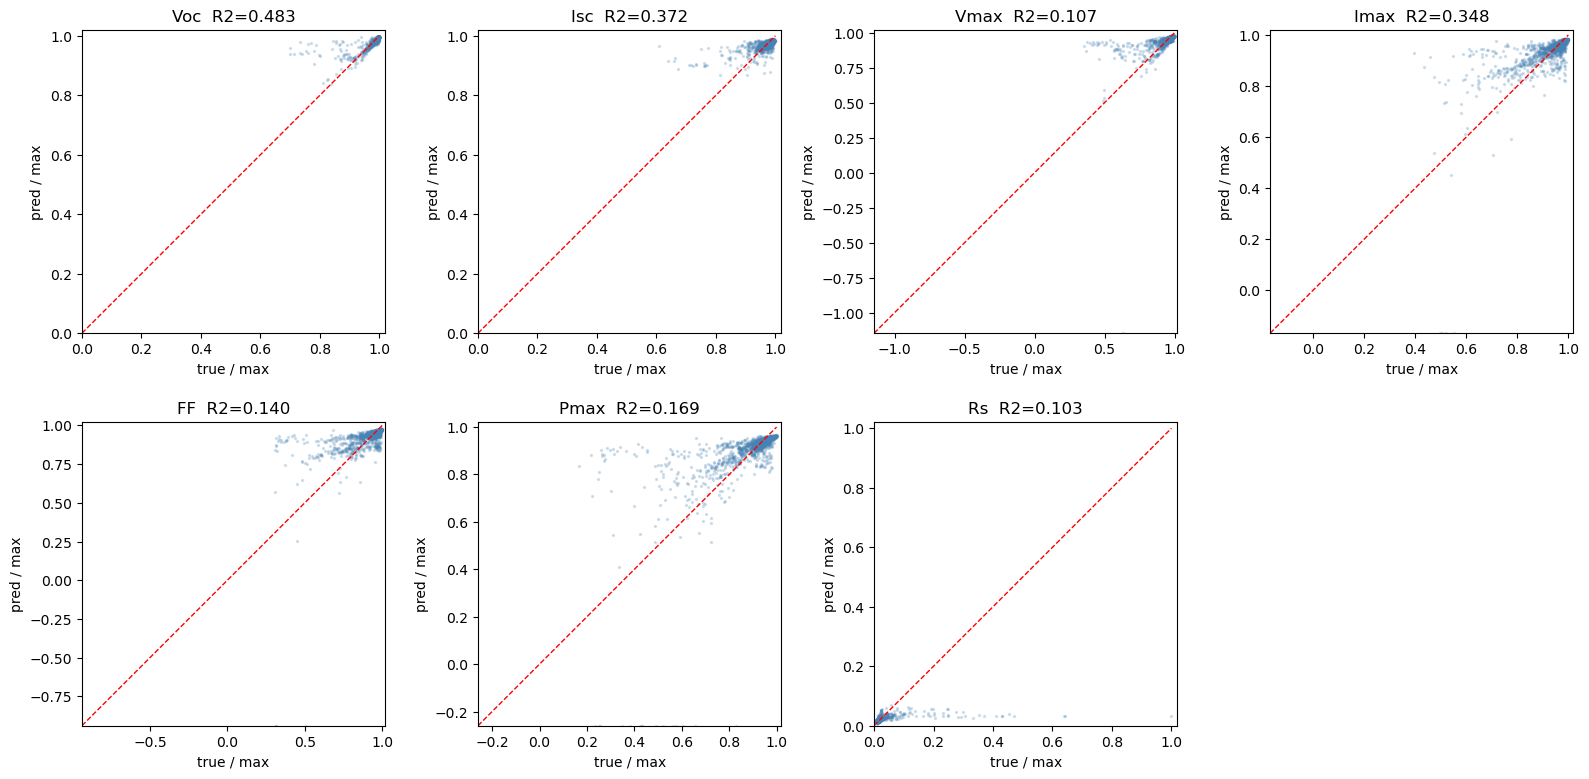

Metrics saved: /storage/homefs/db98d082/ondemand/LUCIA/data/processed/nb6_tierc_metrics_20260630_144408.json


In [13]:
# ── §7.6  Evaluation vs NB3 TileSetIV baseline ───────────────────────────────
# R² per IV target on held-out test set. Same gate as NB3: FF>=0.85, Pmax>=0.87.

if dl_te is None:
    print('Skip §7.6 — DataLoader not available.')
else:
    from sklearn.metrics import r2_score

    vit.eval(); iv_head.eval()
    preds_mu, ivs_true = [], []

    with torch.no_grad():
        for imgs, iv_b in tqdm(dl_te, desc='Evaluating', leave=False):
            cls  = vit(imgs.to(DEVICE))
            pred = iv_head(cls)
            preds_mu.append(pred[:, :, 0].cpu().numpy())
            ivs_true.append(iv_b.numpy())

    preds_mu = np.concatenate(preds_mu)   # (N_test, N_IV) — YJ-scaled
    ivs_true = np.concatenate(ivs_true)   # (N_test, N_IV) — physical

    def inv_yj_np(y_sc, tgt):
        p   = pt_params[tgt]
        yj  = np.asarray(y_sc, np.float32) * p['std'] + p['mu']
        lam = p['lambda']
        if abs(lam) < 1e-6:
            return np.exp(yj) - 1.0
        return np.maximum(lam * yj + 1.0, 1e-8) ** (1.0 / lam) - 1.0

    print('Tier-C TileViT — test R² per target:')
    r2s = {}
    for i, tgt in enumerate(IV_TARGETS):
        ok = ~np.isnan(ivs_true[:, i])
        if ok.sum() < 10: continue
        y_pred = inv_yj_np(preds_mu[ok, i], tgt)
        y_true = ivs_true[ok, i]
        r2 = r2_score(y_true, y_pred)
        r2s[tgt] = float(r2)
        print(f'  {tgt}: R2={r2:.4f}')

    print('\nGate (same as NB3 V5):')
    for tgt, thr in [('FF', 0.85), ('Pmax', 0.87)]:
        if tgt in r2s:
            flag = 'PASS' if r2s[tgt] >= thr else 'FAIL'
            print(f'  {tgt}: {r2s[tgt]:.4f}  -> {flag} (threshold {thr})')

    # ── Parity plots (all 7 IV heads, each normalised so max=1) ────────────────
    _tgts = list(r2s.keys())
    _ncol = 4
    _nrow = int(np.ceil(len(_tgts) / _ncol))
    fig, axes = plt.subplots(_nrow, _ncol, figsize=(4 * _ncol, 4 * _nrow))
    axes = np.atleast_1d(axes).ravel()
    for _j, tgt in enumerate(_tgts):
        ax = axes[_j]
        i  = IV_TARGETS.index(tgt)
        ok = ~np.isnan(ivs_true[:, i])
        _t = ivs_true[ok, i]
        _p = inv_yj_np(preds_mu[ok, i], tgt)
        _mx = max(float(np.nanmax(_t)), float(np.nanmax(_p)), 1e-9)   # normalise so max -> 1
        _tn, _pn = _t / _mx, _p / _mx
        _lo = float(min(_tn.min(), _pn.min(), 0.0))
        ax.scatter(_tn, _pn, s=2, alpha=0.2, color='steelblue')
        ax.plot([_lo, 1], [_lo, 1], 'r--', lw=1)
        ax.set(title=f'{tgt}  R2={r2s[tgt]:.3f}', xlabel='true / max', ylabel='pred / max',
               xlim=(_lo, 1.02), ylim=(_lo, 1.02))
        ax.set_aspect('equal', adjustable='box')
    for _j in range(len(_tgts), len(axes)):   # hide unused axes
        axes[_j].axis('off')
    plt.tight_layout()
    fig.savefig(os.path.join(lc.FIGURES, f'nb6_parity_{RUN_ID}.png'), dpi=120, bbox_inches='tight')
    plt.show()

    metrics_path = os.path.join(lc.PROCESSED, f'nb6_tierc_metrics_{RUN_ID}.json')
    with open(metrics_path, 'w') as _f:
        json.dump({'r2': r2s, 'run_id': RUN_ID,
                   'd_model': D_MODEL, 'depth': DEPTH_ENC}, _f, indent=2)
    print(f'Metrics saved: {metrics_path}')

In [14]:
# ── §7.7  Summary ─────────────────────────────────────────────────────────────
print('=' * 65)
print('NB6 SUMMARY — Tier-C TileViT / MAE (feature-token)')
print('=' * 65)
print(f'  Input:         {N_TILES} tile tokens x {N_FEAT}-d engineered features (Tier-A schema)')
print(f'  TileViT:       d={D_MODEL}  depth={DEPTH_ENC}  heads={N_HEADS}')
print(f'  MAE pre-train: {MAE_EPOCHS}ep  mask_ratio={MASK_RATIO}  (feature-token MAE — fast)')
print(f'  IV fine-tune:  frozen {FT_FROZEN_EP}ep + full {FT_FULL_EP}ep')
print(f'  Loss:          MSE warmup {WARMUP_NLL}ep -> NLL + physics (lambda_c={LAMBDA_C})')
print()
print('Outputs:')
print(f'  models/tierc_vit_mae_*.pt    -- pre-trained ViT encoder + MAE decoder')
print(f'  models/tierc_vit_ft_*.pt     -- fine-tuned ViT + IV heads')
print(f'  processed/nb6_tierc_metrics_*.json')
print()
print('Result (test R² per target):')
for tgt in IV_TARGETS:
    if tgt in r2s:
        print(f'  {tgt:5s}: {r2s[tgt]:.3f}')
_ff, _pm, _rs = r2s.get('FF'), r2s.get('Pmax'), r2s.get('Rs')
print(f"Gate: FF R²={_ff:.3f} ({'PASS' if _ff>=0.85 else 'FAIL'}), "
      f"Pmax R²={_pm:.3f} ({'PASS' if _pm>=0.87 else 'FAIL'}).")
print("Acceptance (feature-token Tier-C vs Tier-A §6.1: FF 0.886, Pmax 0.778, Rs 0.598):")
print(f"  Rs:   Tier-C {_rs:.3f} vs Tier-A 0.598  -> {'>=' if (_rs or 0)>=0.598 else '<'} Tier-A")
print(f"  Pmax: Tier-C {_pm:.3f} vs Tier-A 0.778  -> {'>=' if (_pm or 0)>=0.778 else '<'} Tier-A")
print()
print('Architecture reuse from existing pipeline:')
print('  Tile features    <- lucia_tile_features.parquet (37-d, NB3/Tier-A schema)')
print('  YJ / NLL loss    <- NB3 checkpoint pt_params')
print('  Physics C1/C2    <- NB3 constraint definitions')
print('  Gate thresholds  <- NB3 acceptance gates')

NB6 SUMMARY — Tier-C TileViT / MAE (feature-token)
  Input:         162 tile tokens x 37-d engineered features (Tier-A schema)
  TileViT:       d=256  depth=6  heads=8
  MAE pre-train: 200ep  mask_ratio=0.5  (feature-token MAE — fast)
  IV fine-tune:  frozen 40ep + full 15ep
  Loss:          MSE warmup 20ep -> NLL + physics (lambda_c=0.1)

Outputs:
  models/tierc_vit_mae_*.pt    -- pre-trained ViT encoder + MAE decoder
  models/tierc_vit_ft_*.pt     -- fine-tuned ViT + IV heads
  processed/nb6_tierc_metrics_*.json

Result (test R² per target):
  Voc  : 0.483
  Isc  : 0.372
  Vmax : 0.107
  Imax : 0.348
  FF   : 0.140
  Pmax : 0.169
  Rs   : 0.103
Gate: FF R²=0.140 (FAIL), Pmax R²=0.169 (FAIL).
Acceptance (feature-token Tier-C vs Tier-A §6.1: FF 0.886, Pmax 0.778, Rs 0.598):
  Rs:   Tier-C 0.103 vs Tier-A 0.598  -> < Tier-A
  Pmax: Tier-C 0.169 vs Tier-A 0.778  -> < Tier-A

Architecture reuse from existing pipeline:
  Tile features    <- lucia_tile_features.parquet (37-d, NB3/Tier-A sch